In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from medlib.cstes import swot_dir, drifters_dir
from medlib.swot import browse_swot, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:55: UserWarning: ipyleaflet not available
  warnings.warn("ipyleaflet not available")
/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:56: UserWarning: Some functions will throw an exception if called
  warnings.warn("Some functions will throw an exception if called")


_______
# SWOT

In [2]:
dfs = browse_swot().reset_index()
dfs

,day,pass_number,cycle_number,file,time
0,2023-04-01,3,478,/Users/mdemol/DATA_KARIN/3_478.zarr,2023-04-01 23:42:32.696536000
1,2023-04-02,3,479,/Users/mdemol/DATA_KARIN/3_479.zarr,2023-04-02 23:33:10.425673088
2,2023-04-03,3,480,/Users/mdemol/DATA_KARIN/3_480.zarr,2023-04-03 23:23:48.189185728
3,2023-04-04,3,481,/Users/mdemol/DATA_KARIN/3_481.zarr,2023-04-04 23:14:25.904031360
4,2023-04-05,3,482,/Users/mdemol/DATA_KARIN/3_482.zarr,2023-04-05 23:05:03.656492928
...,...,...,...,...,...
182,2023-07-05,16,573,/Users/mdemol/DATA_KARIN/16_573.zarr,2023-07-05 19:33:50.331633280
183,2023-07-06,16,574,/Users/mdemol/DATA_KARIN/16_574.zarr,2023-07-06 19:24:28.273369600
184,2023-07-07,16,575,/Users/mdemol/DATA_KARIN/16_575.zarr,2023-07-07 19:15:06.145279168
185,2023-07-08,16,576,/Users/mdemol/DATA_KARIN/16_576.zarr,2023-07-08 19:05:44.003893184


In [3]:
dss0 = xr.open_dataset(dfs.iloc[0].file).rename({'longitude':'lon', 'latitude':'lat'}).compute()
dss1 = xr.open_dataset(dfs.iloc[1].file).rename({'longitude':'lon', 'latitude':'lat'}).compute()

In [4]:
dss0

<xarray.Dataset> Size: 434MB
Dimensions:                                  (num_lines: 4160, num_pixels: 519)
Coordinates:
    lat                                      (num_lines, num_pixels) float64 17MB ...
    lon                                      (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/36)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 9MB ...
    cross_track_distance                     (num_lines, num_pixels) float32 9MB ...
    cvl_dac                                  (num_lines, num_pixels) float64 17MB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 17MB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 9MB ...
    cvl_ice_conc                             (num_lines, num_pixels) float64 17MB ...
    ...                                       ...
    pass_number                              (num_lines) uint16 8kB 3 3 ... 3 3
    sig0_karin_2                             (num_lines, num_pixels) float32 9MB ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 17MB ...
    time                                     (num_lines) datetime64[ns] 33kB ...
    time_tai                                 (num_lines) datetime64[ns] 33kB ...
    version                                  (num_lines) |S7 29kB b'PGC0_02' ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750102

In [5]:
def get_proj(lonc, latc):  # converts from lon, lat to native map projection x,y
    """Create pyproj Proj object, project is an azimutal Eqsuidistant projection centered on the central point of the selected satellite track = matching point
    https://proj.org/operations/projections/aeqd.html

    Parameters
    ----------
    lonc,latc : float
        central longitude and latitude of the satellite track, matching point on which the box will be centered
    Return
    ------
    pyproj.Proj object
    """
    return pyproj.Proj(
        proj="aeqd", lat_0=latc, lon_0=lonc, datum="WGS84", units="m"
    )  # aeqd Azimutal EQuiDistant projection centered on lonc,latc


def lonlat2xy(lonc, latc, phi, lon, lat, lon1=None, lat1=None):
    """return coordinates with origin at (lonc, latc) and x-axis aligned
    with (lonc, latc) - (lon1, lat1) direction (lon,lat -> x-along satellite track, y-normal to satellite track)

    Parameters
    ----------
    lonc, latc, phi: float
        central position and orientation of the box
    lon, lat : np.array, np.array
        local grid of the box
    lon1,lat1 : float
        end of the satellite track

    Return
    ------
    local x, local y : np.array, np.array

    """
    proj = get_proj(lonc, latc)
    # get local coordinate
    xc, yc = proj.transform(lonc, latc)
    xl, yl = proj.transform(lon, lat)
    if phi is None:
        # compute phi from x1 and y1
        x1, y1 = proj.transform(lon1, lat1)
        # get orientation of defined by central point and point 1
        phi = np.arctan2(y1 - yc, x1 - xc) * 180 / np.pi
    # build affine operators
    a_fwrd = Affine.translation(-xc, -yc) * Affine.rotation(-phi, pivot=(xc, yc))
    # a_back = ~a_fwrd

    x, y = a_fwrd * (xl, yl)

    return x, y

In [9]:
lond, latd = (5, 41)
xd, yd = lonlat2xy(dss0.attrs['lonc'],dss0.attrs['latc'], dss0.attrs['phi'], lond, latd, lon1=None, lat1=None)

In [10]:
xd, yd

(124478.10060965866, -24845.89273099015)

In [7]:
x, y = lonlat2xy(dss0.attrs['lonc'],dss0.attrs['latc'],  dss0.attrs['phi'], dss0.lon, dss0.lat, lon1=None, lat1=None)
dss0['x']= xr.DataArray(x, dims=['num_lines', 'num_pixels'])
dss0['y']= xr.DataArray(y, dims=['num_lines', 'num_pixels'])
dss0 = dss0.set_coords(['x', 'y'])

In [48]:
ggrad_var = ['duacs_ssha_karin_2_calibrated','duacs_ssha_karin_2_filtered','cvl_mean_dynamic_topography_cnes_cls_22','cvl_mean_sea_surface_cnes_22_hybrid','cvl_ocean_tide_fes_2022','cvl_ssha_reference','cvl_swh_model',]

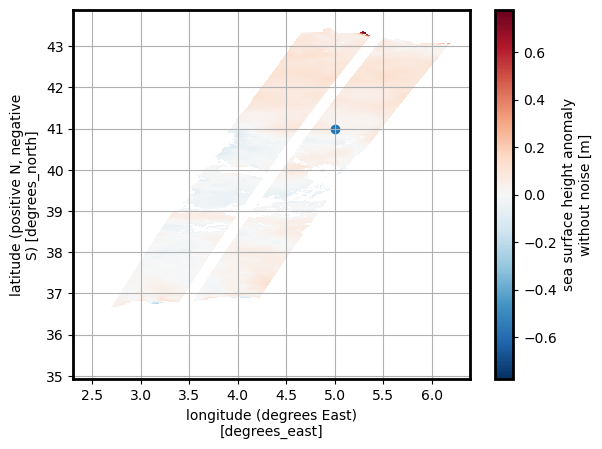

In [49]:
dss0.duacs_ssha_karin_2_filtered.plot(x='lon', y='lat')
plt.scatter(lond, latd)
plt.grid()

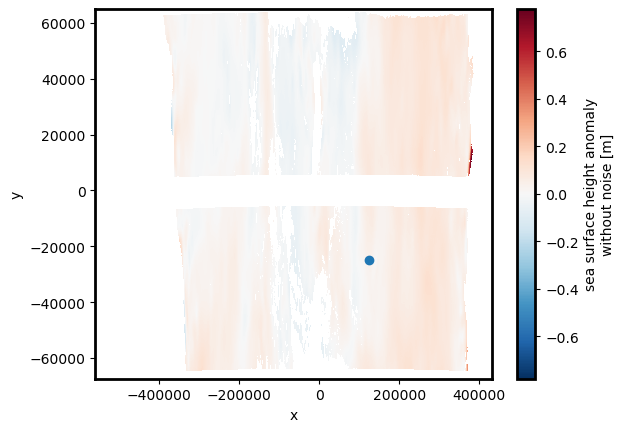

In [50]:
dss0.duacs_ssha_karin_2_filtered.plot(x='x', y='y')
plt.scatter(xd, yd)

In [129]:
dl = 2.5*1000
test_x = (dss0.x > xd-dl) & (dss0.x<xd+dl)
ds_ = dss0.where(test_x, drop=True)
test_y = (ds_.y > yd-dl) & (ds_.y<yd+dl)
ds_ = ds_.where(test_y, drop=True)
ds_

<xarray.Dataset> Size: 127kB
Dimensions:                                  (num_lines: 22, num_pixels: 20)
Coordinates:
    lat                                      (num_lines, num_pixels) float64 4kB ...
    lon                                      (num_lines, num_pixels) float64 4kB ...
    x                                        (num_lines, num_pixels) float64 4kB ...
    y                                        (num_lines, num_pixels) float64 4kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/36)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 2kB ...
    cross_track_distance                     (num_lines, num_pixels) float32 2kB ...
    cvl_dac                                  (num_lines, num_pixels) float64 4kB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 4kB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 2kB ...
    cvl_ice_conc                             (num_lines, num_pixels) float64 4kB ...
    ...                                       ...
    pass_number                              (num_lines, num_pixels) float32 2kB ...
    sig0_karin_2                             (num_lines, num_pixels) float32 2kB ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 4kB ...
    time                                     (num_lines, num_pixels) datetime64[ns] 4kB ...
    time_tai                                 (num_lines, num_pixels) datetime64[ns] 4kB ...
    version                                  (num_lines, num_pixels) object 4kB ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750102

In [86]:
box_x = np.arange(ds_.x.min(), ds_.x.max(), 125)
box_y = np.arange(ds_.y.min(), ds_.y.max(), 125)

In [123]:
ds_ = ds_.where(ds_.duacs_ssha_karin_2_filtered!=np.nan, drop=True)

In [173]:
from scipy.interpolate import interp2d

Z = ds_.duacs_ssha_karin_2_filtered.values.ravel()
X = ds_.x.values.ravel()
Y = ds_.y.values.ravel()
_ds = xr.Dataset(data_vars=dict(x=(["a"], X), y=(["a"], Y), z=(["a"], Z)))
_ds = _ds.dropna('a')


f = interp2d(_ds.x, _ds.y, _ds.z)
Znew = f(box_x, box_y)

In [176]:
len(box_x), len(box_y)

(41, 39)

In [177]:
np.shape(Znew)

(39, 41)

In [179]:
da = xr.DataArray(Znew, coords={'x':box_x, 'y':box_y}, dims=[ 'y', 'x'])

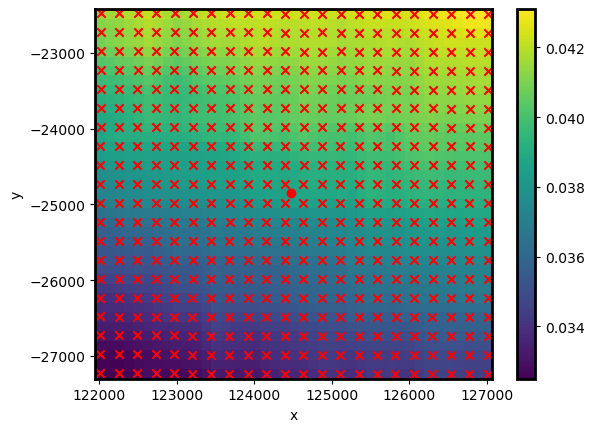

In [187]:
da.plot()
plt.scatter(X, Y, marker = 'x', c='r')
plt.scatter(xd, yd, c='r')

In [181]:
dax = da.differentiate('x')
day = da.differentiate('y')

In [184]:
dax.interp(x=xd, y=yd)

<xarray.DataArray ()> Size: 8B
array(8.71644815e-07)
Coordinates:
    x        float64 8B 1.245e+05
    y        float64 8B -2.485e+04

In [47]:
for x, y in 

<xarray.DataArray (x: 6720, y: 6720)> Size: 361MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * x        (x) float64 54kB 1.146e+05 1.146e+05 ... 1.344e+05 1.344e+05
  * y        (y) float64 54kB -3.475e+04 -3.475e+04 ... -1.497e+04 -1.497e+04

In [23]:
meshgrid = np.meshgrid(ds_.x, ds_.y)

In [26]:
meshgrid[0]

array([[114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958],
       [114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958],
       [114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958],
       ...,
       [114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958],
       [114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958],
       [114636.20345532, 114635.90013779, 114635.59617075, ...,
        134389.20283387, 134388.71670988, 134388.29038958]])

In [9]:
a= dss0.duacs_ssha_karin_2_filtered

In [10]:
b = a.to_dataframe().reset_index()[['x', 'y', 'duacs_ssha_karin_2_filtered']]#.stack()
b

,x,y,duacs_ssha_karin_2_filtered
0,-559974.050160,62338.801187,NaN
1,-559973.976998,62089.490050,NaN
2,-559973.768907,61840.111295,NaN
3,-559973.661811,61590.708210,NaN
4,-559975.211238,61800.177691,NaN
...,...,...,...
2159035,431413.835084,-65213.748531,NaN
2159036,431412.339447,-65459.407365,NaN
2159037,431413.218046,-65710.215033,NaN
2159038,431414.085583,-65960.946611,NaN


In [12]:
b['couple'] = list(zip(b.x, b.y))

In [15]:
b = b.set_index(b.couple).drop(columns=['couple'])
b

AttributeError: 'DataFrame' object has no attribute 'couple'

In [20]:
b.stack()

couple                                     
(-559974.050160301, 62338.801187063145)   x   -559974.050160
                                          y     62338.801187
(-559973.9769983772, 62089.49005018214)   x   -559973.976998
                                          y     62089.490050
(-559973.7689073774, 61840.11129457982)   x   -559973.768907
                                                   ...      
(431413.2180462787, -65710.21503274202)   y    -65710.215033
(431414.0855834361, -65960.94661069974)   x    431414.085583
                                          y    -65960.946611
(431415.09012013045, -66211.73063962965)  x    431415.090120
                                          y    -66211.730640
Length: 5609787, dtype: float64

In [16]:
c = b.to_xarray()

In [17]:
c

<xarray.Dataset> Size: 69MB
Dimensions:                      (couple: 2159040)
Coordinates:
  * couple                       (couple) object 17MB (-559974.050160301, 623...
Data variables:
    x                            (couple) float64 17MB -5.6e+05 ... 4.314e+05
    y                            (couple) float64 17MB 6.234e+04 ... -6.621e+04
    duacs_ssha_karin_2_filtered  (couple) float64 17MB nan nan nan ... nan nan